# Reconstruction of the dynamical system in 3D

## Setup

### Packages and functions

In [1]:
using LinearAlgebra, GLMakie
using StatsBase: mean, sample, wsample, median
import Random

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: spa

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

ax3d(f;azymuth=0.4pi,kwargs...) = # 0.7pi or 0.4pi
    Axis3(
        f, viewmode=:fitzoom, aspect=:data, azimuth=azymuth,
        xlabel=varnames[1], ylabel=varnames[2], zlabel=varnames[3],
        protrusions=(30,0,30,0)
    )

ax3d (generic function with 1 method)

### Makie theme

In [2]:
if false
    # for figure: white BG, vector graphics
    import CairoMakie
    CairoMakie.activate!(type="svg")
    linecolor = :black
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use: dark BG, raster graphics
    using GLMakie
    GLMakie.activate!(px_per_unit=1)
    linecolor = :black
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Model definition

In [3]:
varnames = ["x","y","z"]
#modelname = "Feedback loop"
modelname = "Lorenz system"

if modelname == "Lorenz system"
    f(x,y,z; p=10, r=28, b=8/3) = [-p*x + p*y, -x*z + r*x - y, x*y - b*z]
else # "Feedback loop"
    hf(x;n=2) = 1/(1+x^n) # hill-like function
    f(x,y,z;a=1,b=1,c=1) = [hf(z;n=20)-a*x,x-b*y,y-c*z]
    f(x,y,z;a=1,b=1,c=1) = [hf(z;n=12)-a*x,x-b*y,y-c*z/(1+z)]
end

vf(x) = f(x...)

vf (generic function with 1 method)

## Simulate trajectories

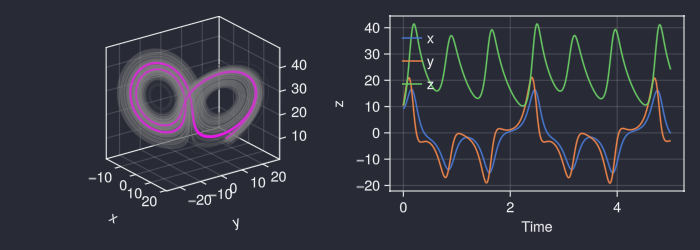

In [4]:
N = 2000
ns = 500
dt = modelname == "Lorenz system" ? 0.01 : 0.1
init = modelname == "Lorenz system" ?
    () -> randn(3) + fill(10.,3) :
    () -> rand(0..2,3)

cpal = resample_cmap(:seaborn_muted,10)
Random.seed!(111)
trajs = [kutta(spa(f),init(),s=ns,dt=dt) for _ in 1:N]

let
    fig = Figure(size=(700,250),)
    ax1 = ax3d(fig[1,1],title=modelname,azymuth=-0.2pi)
    for i in sample(1:N,100)
        lines!(ax1,Point3f.(eachcol(trajs[i])),color=:grey,transparency=true,linewidth=0.1)
    end
    lines!(ax1,Point3f.(eachcol(last(trajs))),color=:magenta,transparency=true,linewidth=2)
    ax2 = Axis(fig[1,2],xlabel="Time")
    [lines!(ax2,0:dt:dt*ns,last(trajs)[i,:],label=varnames[i],color=cpal[i]) for i in 1:3]
    axislegend(ax2,position = :lt)
    fig
end

### the movie

In [5]:
vio = let lw=3, tmax=ns, tshow=10, by=1, ishow=sample(1:N,10)
    trsp = true # transparency
    time = Observable(0.0)
    traj = Observable(Point3f[])
    amps = [Observable(Point2f[]) for _ in 1:3]
    cols = Observable(Int[])
    with_theme(theme_dark(),fontsize=14,backgroundcolor=RGBf([36,37,46]/255...)) do
        fig = Figure(size=(900,400))
        ax1 = ax3d(fig[1,1],azymuth=-0.2pi)
        for i in ishow
            lines!(ax1,Point3f.(eachcol(trajs[i])),color=:white,transparency=trsp,linewidth=0.1)
        end
        ln = lines!(ax1,traj,transparency=trsp,linewidth=lw,color=cols,colormap=Reverse(:deep))
        ax2 = Axis(fig[1,2],xlabel="Time (sec.)",limits=(0,dt*tmax,extrema(trajs[tshow][1:3,:])...))
        [lines!(ax2,amps[i],label=varnames[i],color=cpal[i]) for i in 1:3]
        axislegend(ax2,position=:rb)
        vio = Record(fig, 1:by:tmax; framerate=30, profile ="high") do i
            time[] = dt*i
            push!(cols[],i)
            push!(traj[],Point3f(trajs[tshow][1:3,i]))
            i > 100 && popfirst!.([traj[],cols[]])
            [push!(amps[j][],Point2f(time[],trajs[tshow][j,i])) for j in 1:3]
            notify.([traj,cols,amps...])
        end
    end
end

VideoStream(Base.PipeEndpoint(RawFD(78) open, 0 bytes waiting), Process(setenv(`/home/kazumitsu.maehara/.julia/artifacts/5b83972689fb7dea5e89326f1c0ba60d68e962fb/bin/ffmpeg -y -loglevel quiet -threads 48 -framerate 30 -pixel_format rgb24 -f rawvideo -s:v 900x400 -r 30 -i pipe:0 -vf vflip -profile:v high -crf 20 -preset slow -c:v libx264 -pix_fmt yuv420p -an '/tmp/jl_ZU8aNt/##video#230.mp4'`,["XKB_CONFIG_ROOT=/home/kazumitsu.maehara/.julia/artifacts/f8b49c7c45b400e3f5c4002d19645d4b88712c0c/share/X11/xkb", "PATH=/home/kazumitsu.maehara/.julia/artifacts/b8a470e4553346122607f94ec60d83c77f061cd6/bin:/home/kazumitsu.maehara/.julia/artifacts/7f882b869c126a717e15be05453b83bd9135eab0/bin:/home/kazumitsu.maehara/.julia/artifacts/96bc7b9ddb319d1a051535c85184aa2bf42dbd8b/bin:/home/kazumitsu.maehara/.julia/artifacts/bd752d7807f5f10e2dce3d2b2b683589fa03d31a/bin:/home/kazumitsu.maehara/.julia/artifacts/c8a20a2030f10b70947d8d2a6bff7f8b5f343fe9/bin:/home/kazumitsu.maehara/.julia/artifacts/0b5269206a6849e48487ed04136c30b1f12443e7/bin:/home/kazumitsu.maehara/.julia/artifacts/587de110e5f58fd435dc35b294df31bb7a75f692/bin:/home/kazumitsu.maehara/.julia/artifacts/fc239b3ff5739aeab252bd154fa4dd045fefe629/bin:/home/kazumitsu.maehara/.julia/artifacts/8be4b2d49ed77db4f9607e5f8a7b09cc105be2ee/bin:/home/kazumitsu.maehara/.julia/artifacts/5b83972689fb7dea5e89326f1c0ba60d68e962fb/bin:/usr/local/packages/mambaforge/bin", "JULIA_PROJECT=@.", "JPY_SESSION_NAME=/home/kazumitsu.maehara/pynb/ddHodge_figures/notebook/sim3D_fig.ipynb", "DISPLAY=:1", "COLUMNS=80", "JUPYTERHUB_BASE_URL=/", "SHELL=/bin/bash", "JUPYTERHUB_OAUTH_ACCESS_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JPY_API_TOKEN=75189a2751e8474d83eec23039d06929"  …  "LINES=30", "JUPYTERHUB_DEFAULT_URL=/lab", "LIBDECOR_PLUGIN_DIR=/home/kazumitsu.maehara/.julia/artifacts/38e215c51e5c0f77bc7a8813ba4586632a8fc750/lib/libdecor/plugins-1", "HOME=/home/kazumitsu.maehara", "JUPYTERHUB_USER=kazumitsu.maehara", "JUPYTERHUB_CLIENT_ID=jupyterhub-user-kazumitsu.maehara", "JUPYTERHUB_COOKIE_HOST_PREFIX_ENABLED=0", "JUPYTERHUB_OAUTH_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JUPYTERHUB_SERVICE_PREFIX=/user/kazumitsu.maehara/", "OPENBLAS_MAIN_FREE=1"]), ProcessRunning), GLMakie.Screen(...), Makie.TickController(Observable(Makie.Tick(Makie.OneTimeRenderTick, 500, 16.666666666666668, 0.03333333333333333)), 501, 0.03333333333333333, true, ObserverFunction defined at /home/kazumitsu.maehara/.julia/packages/Makie/ux0Te/src/ffmpeg-util.jl:191 operating on Observable(Tick(OneTimeRenderTick, 500, 16.6667, 0.0333333))), ColorTypes.RGB{FixedPointNumbers.N0f8}[RGB(0.141, 0.145, 0.18) RGB(0.141, 0.145, 0.18) … RGB(0.2, 0.204, 0.239) RGB(0.141, 0.145, 0.18); RGB(0.0, 0.141, 0.145) RGB(0.0, 0.141, 0.145) … RGB(0.0, 0.2, 0.204) RGB(0.0, 0.141, 0.145); … ; RGB(0.18, 0.0, 0.141) RGB(0.18, 0.0, 0.141) … RGB(0.18, 0.0, 0.141) RGB(0.18, 0.0, 0.141); RGB(0.145, 0.18, 0.0) RGB(0.145, 0.18, 0.0) … RGB(0.145, 0.18, 0.0) RGB(0.145, 0.18, 0.0)], "/tmp/jl_ZU8aNt/##video#230.mp4", Makie.VideoStreamOptions("mp4", 30, 20, "high", "yuv420p", 0, "quiet", "pipe:0", true))

## Uniform sampling on the trajectories

In [6]:
Random.seed!(111)
X = if modelname=="Hamiltonian"
    hcat([trajs[i][:,rand(1:ns)] for i in 1:N]...)
else
    let warmup = 50
        hcat([trajs[i][:,rand(warmup:ns)] for i in 1:N]...)
    end
end

pts = Point3f.(eachcol(X))
# PCA for visualization
μ = mean(pts)
S = svd(X.-μ).U[:,1:2] #*diagm([-1,1])
Xe = S'*(X.-μ)
pts2 = Point2f.(eachcol(Xe))
V = mapslices(vf,X,dims=1)

3×2000 Matrix{Float64}:
  76.9611   43.783   67.5639  -18.9579  …  -24.2764    23.6933  -16.1116
  40.5459  208.963  141.088   -36.7432       7.14676   42.9089  -13.6154
 -93.0672   68.118  -26.8215  -21.9575     -61.8293   -16.8     -44.7879

## ddHodge workflow

In [7]:
using ddHodge
struct Params
    k::Int
    d::Int
    λ::AbstractFloat
    ϵ::AbstractFloat
end
par = Params(20,2,0.1,1.0)
g, kdtree = kNNGraph(X,par.k)
ddh = ddHodgeWorkflow(g,X,V,rdim=par.d,λ=par.λ,ϵ=par.ϵ,ssa=true,ssart=1,krytol=1e-32)

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.242 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 0.9854686773961897
[ Info: ... done in 0.916 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 3.124 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 0.9978456469395514
[ Info: ... done in 2.93 sec.


:::ddHodgge::: values over graph {2000, 23673}, dimensions: 3 -> 2 (ssa: on)

## Show results

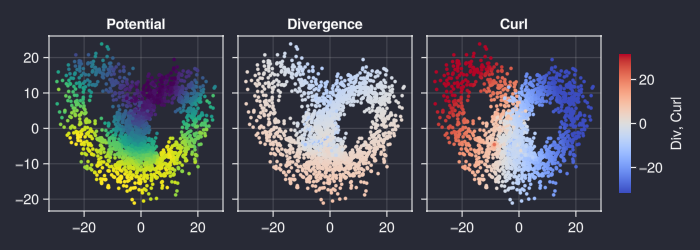

In [8]:
let ms = 5
    fig = Figure(size=(700,250))
    titles = ["Potential", "Divergence", "Curl"]
    axs = [Axis(fig[1,i],title=titles[i],aspect=1) for i in 1:length(titles)]
    scatter!(axs[1], pts2, color=clip(ddh.u), colormap=:viridis, markersize=ms)
    vmax = clipmax([ddh.rot;ddh.div],p=0.05)
    plt = scatter!(axs[2], pts2, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax))
    scatter!(axs[3], pts2, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax))
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    colgap!(fig.layout,10)
    Colorbar(fig[1,4],plt,height=Relative(0.8),label="Div, Curl")
    fig
end

## Projecting analytical ... may success

In [9]:
import ForwardDiff
Jf(x) = ForwardDiff.jacobian(spa(f),x)

Jf (generic function with 1 method)

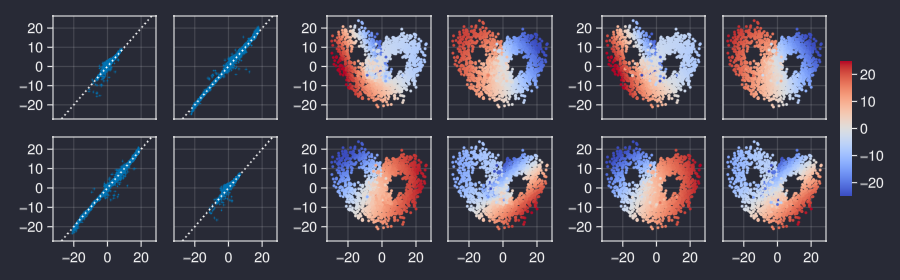

In [10]:
let
    E = Matrix(1.0I,3,3) # cannonical basis
    Ja = [basischange(Jf(pts[i]),E,ddh.frames[i]) for i in 1:N]
    getelm(x;i,j) = x[i,j]
    fdim = size(ddh.J[begin],1)
    fig = Figure(size=(900,280))
    axs = [Axis(fig[i,j],aspect=1) for i in 1:fdim, j in 1:3fdim]
    for i in 1:fdim, j in 1:fdim
        scatter!(axs[i,j],getelm.(ddh.J;i,j),getelm.(Ja;i,j),markersize=2)
        ablines!(axs[i,j],[0],[1],color=:white,linestyle=:dot)
    end
    for i in 1:fdim, j in 1:fdim
        vals = getelm.(ddh.J;i,j)
        vmax = clipmax(vals,p=0.01)
        scatter!(axs[i,j+2],pts2,color=vals,colormap=:coolwarm,colorrange=(-vmax,vmax),markersize=4)
    end
    for i in 1:fdim, j in 1:fdim
        vals = getelm.(Ja;i,j)
        vmax = clipmax(vals,p=0.01)
        scatter!(axs[i,j+4],pts2,color=vals,colormap=:coolwarm,colorrange=(-vmax,vmax),markersize=4)
    end
    vmax = maximum(abs.(hcat(Ja...)))
    Colorbar(fig[1:2,7],colormap=:coolwarm,colorrange=(-vmax,vmax),height=Relative(0.6))
    hideydecorations!.(axs[:,2:fdim], grid = false)
    hideydecorations!.(axs[:,fdim+2:2fdim], grid = false)
    hideydecorations!.(axs[:,2fdim+2:3fdim], grid = false)
    hidexdecorations!.(axs[1:fdim-1,:], grid = false)
    colgap!(fig.layout,10)
    linkaxes!(axs...)
    fig
end

## Upscaling estimates ... may fail

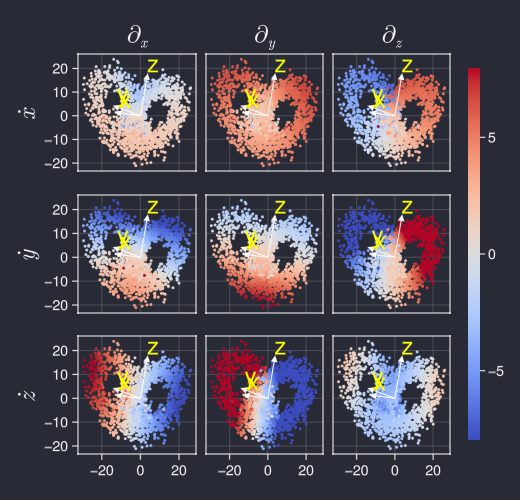

In [11]:
let analytical=false, axes=true, fdim=3
    α = 0.5maximum(norm.(pts2))
    if analytical
        Js = Jf.(eachcol(X))
    else
        Js = map(1:N) do i
            J = ddh.J[i]
            Ψ = ddh.frames[i]
            Ψ*J*((Ψ'*Ψ)\Ψ') # Jacobian matrix in I
        end
    end
    vmax = clipmax(vec(hcat(Js...)),p=0.05)
    fig = Figure(size=(520,500))
    axs = [Axis(fig[i,j],aspect=1,titlesize=24,ylabelsize=24) for i in 1:fdim, j in 1:fdim]
    for i in 1:fdim, j in 1:fdim
        vals = [J[i,j] for J in Js]
        scatter!(axs[i,j],pts2,color=vals,colormap=:coolwarm,colorrange=(-vmax,vmax),markersize=4)
        if axes
            arrows!(axs[i,j],fill(Point2f(0),fdim),eachrow(α*S),color=:white)
            text!(axs[i,j],Point2f.(eachrow(α*S)),text=varnames,color=:yellow,fontsize=24,)#font="Bold")
        end
    end
    [axs[i,1].ylabel=L"\dot{%$(varnames[i])}" for i in 1:fdim]
    [axs[1,j].title=L"\partial_{%$(varnames[j])}" for j in 1:fdim]
    linkaxes!(axs...)
    colgap!(fig.layout,10)
    rowgap!(fig.layout,10)
    hideydecorations!.(axs[:,2:fdim], grid = false)
    hidexdecorations!.(axs[1:fdim-1,:], grid = false)
    Colorbar(fig[1:fdim,fdim+1],colormap=:coolwarm,colorrange=(-vmax,vmax),height=Relative(0.9),vertical=true)
    fig
end

## Grassmann distance

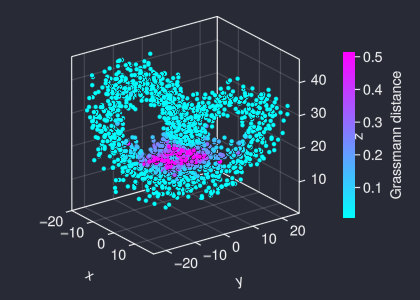

In [12]:
let
    fig = Figure(size=(420,300))
    ax = ax3d(fig[1,1],azymuth=-0.2pi)
    plt = scatter!(ax,pts,color=clip(ddh.vgrass,0.05),markersize=6,colormap=:cool)
    Colorbar(fig[1,2],plt,label="Grassmann distance",height=Relative(0.7))
    fig
end

## Local dynamics

2-element Vector{ComplexF64}:
 -0.2891704959750365 + 18.847093398209708im
 -0.2891704959750365 - 18.847093398209708im

2-element Vector{ComplexF64}:
 -0.2891704959750365 + 18.847093398209708im
 -0.2891704959750365 - 18.847093398209708im

rank([J * svecs svecs]) = 2


3×2 Matrix{Float64}:
 0.447965   0.179903
 0.867075  -0.430827
 0.307525   0.857297

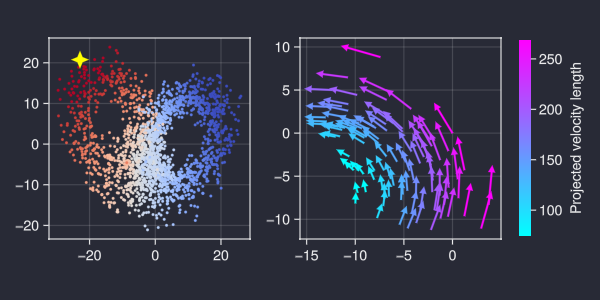

In [13]:
let x = ddh.rot, thr=0.05, nnei=100, cmap=:coolwarm, i=argmax(x), suse=[1,2]
    nei = ddHodge.knn(kdtree,X[:,i],nnei,true)[1]
    S = ddh.spans[i]
    Ψ = ddh.frames[i]
    J = ddh.J[i] # Jacobian matrix in Ψ
    #Jorth = S'*Ψ*J*((Ψ'*Ψ)\(Ψ'*S)) # Jacobian matrix in S
    sf = schur(J)
    display(sf.values)
    svals, svecs = schurselect(sf,suse)
    display(svals)
    @show rank([J*svecs svecs])
    #U = Ψ*rvecs[:,1:2]
    U = Ψ*svecs*diagm([1,-1])
    display(U)
    xoi = U'*(X[:,nei].-X[:,i]) |> eachcol .|> Point2f
    voi = U'*V[:,nei] |> eachcol .|> Point2f
    vali = x[nei]
    vmax = clipmax(x,p=thr)
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=1)
    scatter!(ax1,pts2,markersize=4,color=x,colorrange=(-vmax,vmax),colormap=cmap)
    scatter!(ax1,pts2[i],marker=:star4,markersize=20,color=:yellow)
    ax2 = Axis(fig[1,2],aspect=1)
    α = 0.1*((x,y) -> norm(x-y))(extrema(xoi)...)/median(norm.(voi))
    arr = arrows!(ax2,xoi,α*voi,color=clip(norm.(voi),thr),arrowsize=10,colormap=:cool,linewidth=2)
    sca = scatter!(ax2,xoi,color=vali,colormap=cmap,markersize=0,colorrange=(-vmax,vmax))
    Colorbar(fig[1,3],arr,height=Relative(0.8),label="Projected velocity length")
    fig
end
#end

In [14]:
if par.d == 3
fig = let x = ddh.rot, thr=0.05, nnei=200, cmap=:coolwarm, suse=[2,3], i=argmax(ddh.rot) #findfirst((ddh.rot .> 40) .& (X[3,:] .> 20))
    nei = ddHodge.knn(kdtree,X[:,i],nnei,true)[1]
    B = ddh.spans[i]
    J = basischange(ddh.J[i],ddh.frames[i],B)
    sf = schur(J)
    display(sf.values)
    svals, svecs = schurselect(sf,suse)
    display(svals)
    @show rank([J*svecs svecs])
    U = B*svecs
    rps = Point3f.(eachcol(10U))
    nv = normalize(U[:,1] × U[:,2])
    @show rps, nv
    b = pts[i]
    vmax = clipmax(x,p=thr)
    fig = Figure(size=(400,300))
    ax = ax3d(fig[1,1],azymuth=-0.2pi)
    #ax = Axis3(fig[1,1],azimuth=-0.2pi)
    scatter!(ax,pts,color=ddh.rot,transparency=true,markersize=6,colormap=:coolwarm,colorrange=(-vmax,vmax),rasterize=false)
    arrows!(ax,[b,b],Point3f.([0.5rps[1],0.5rps[2]]),linewidth=0.5,arrowsize=3,color=[:salmon,:skyblue],transparency=false)
    #arrows!(ax,[b,b,b],Point3f.([0.5rps[1],0.5rps[2],10nv]),linewidth=0.5,arrowsize=2,color=[:salmon,:skyblue,:purple],transparency=true)
    #arrows!(ax,[b,b,b],Point3f.([0.5rps[1],0.5rps[2],0.5nv]),color=[:salmon,:skyblue],linewidth=0.5,arrowsize=2,rasterize=true)
    for (a1,a2) = [(1,1),(1,-1),(-1,1),(-1,-1)]
        mesh!(ax,Point3f.([b,a1*rps[1]+b,a2*rps[2]+b]),color=(:lightgrey,0.5),transparency=true,shading=NoShading)
    end
    fig
end
end

## 1st order taylor approximation
$\bm f(\bm x) \approx \bm f(\bm x_0) + J(\bm x_0)\bm x$

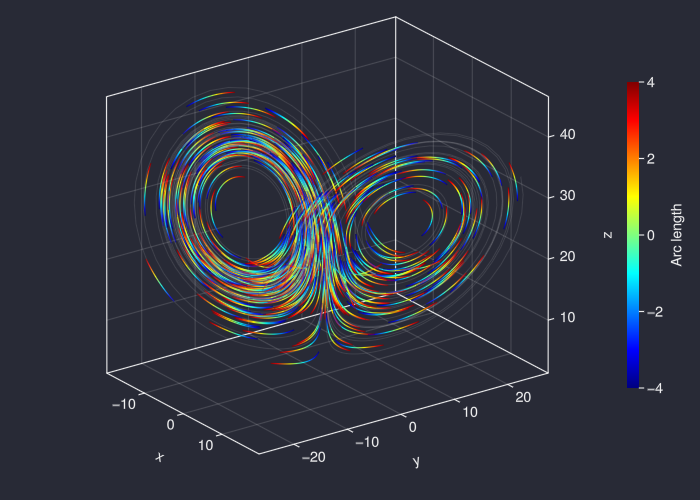

In [15]:
fig = let i = argmin(ddh.rot), ns=40, dt=0.1
    fig = Figure(size=(700,500))
    ax = ax3d(fig[1,1],azymuth=-0.2pi)
    #scatter!(ax,pts,markersize=4,color=(:white,0.6),transparency=true)
    for i in sample(1:N,10)
        lines!(ax,Point3f.(eachcol(trajs[i][:,50:end])),color=:white,transparency=true,linewidth=0.1)
    end
    ln = []
    for j in sample(1:N,500)
        B = ddh.spans[j] # can be i
        Jp = basischange(ddh.J[j],ddh.frames[j],B)
        fp = B'*V[:,j]
        trajbw, trajfw = [
            # velocities are normalized to force unit arc length
            kutta(x -> normalize(fp + Jp*x),fill(0.0,ddh.rdim),s=ns,dt=dt*dir) for dir=[-1,1]
        ]
        traj = B*hcat(reverse(trajbw,dims=2),trajfw[:,2:end]) .+ X[:,j]
        ln = lines!(ax,traj[1:3,:],color=dt.*(-ns:ns),colormap=:jet,linewidth=1,transparency=true)
        #scatter!(ax,Point{ddh.rdim,Float32}(X[:,i]),markersize=4,color=:white)
    end
    Colorbar(fig[1,2],ln,height=Relative(0.7),label="Arc length")
    fig
end